In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
from torch.utils.data import Dataset
from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate
import h5py

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [2]:
 # Load data
BATCH_SIZE = 512
filename = r"train_test_split_soft_fp16.h5"

def quarter(pattern):
    return pattern[:32, :32]  # downsample to 32x32

# Custom Dataset class
class NeffDataset(Dataset):
    def __init__(self, patterns, params, targets):
        self.patterns = torch.FloatTensor(patterns)
        self.params = torch.FloatTensor(params)
        self.targets = torch.FloatTensor(targets)
    
    def __len__(self):
        return len(self.patterns)
    
    def __getitem__(self, idx):
        return self.patterns[idx], self.params[idx], self.targets[idx]
    
def load_data(filename):
    """Load and process data from HDF5 file"""
    with h5py.File(filename, "r") as f:
        neff_train = np.array(f['neff_train'])
        weight_train = np.array(f['weight_train'])
        params_train = np.array(f['params_train'])
        pattern_train = np.array(f['pattern_train'])  # shape [N, 64, 64]
        
        neff_test = np.array(f['neff_test'])
        weight_test = np.array(f['weight_test'])
        params_test = np.array(f['params_test'])
        pattern_test = np.array(f['pattern_test'])  # shape [M, 64, 64]
    
    # Apply quarter() to every pattern (vectorized alternative)
    pattern_train_quartered = pattern_train[:, :32, :32]  # shape [N, 32, 32]
    pattern_test_quartered  = pattern_test[:, :32, :32]   # shape [M, 32, 32]

    # Reshape for downstream use if needed
    xs  = pattern_train_quartered[:, np.newaxis, :, :]
    xs1 = pattern_test_quartered[:,  np.newaxis, :, :]

    x1s  = params_train
    x1s1 = params_test
    ys   = neff_train[:, 0:1]
    ys1  = neff_test[:, 0:1]
    
    return xs, x1s, ys, xs1, x1s1, ys1

def create_dataloaders(xs, x1s, ys, xs1, x1s1, ys1, batch_size=256):
    """Create training and test dataloaders with Windows-compatible settings"""
    train_dataset = NeffDataset(xs, x1s, ys)
    test_dataset = NeffDataset(xs1, x1s1, ys1)
    
    # Use single process for Windows compatibility
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=0,  # Use 0 for Windows compatibility
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=0,  # Use 0 for Windows compatibility
        pin_memory=True
    )
    
    return train_loader, test_loader


try:
    xs, x1s, ys, xs1, x1s1, ys1 = load_data(filename)
    print(f"Training data shape: {xs.shape}")
    print(f"Training params shape: {x1s.shape}")
    print(f"Training targets shape: {ys.shape}")
    print(f"Test data shape: {xs1.shape}")
    print(f"Test params shape: {x1s1.shape}")
    print(f"Test targets shape: {ys1.shape}")
except FileNotFoundError:
    print(f"Data file not found: {filename}")
    print("Please update the filename path")
    exit()

# Create dataloaders
train_loader, test_loader = create_dataloaders(xs, x1s, ys, xs1, x1s1, ys1, batch_size=BATCH_SIZE)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Training data shape: (1113998, 1, 32, 32)
Training params shape: (1113998, 4)
Training targets shape: (1113998, 1)
Test data shape: (477427, 1, 32, 32)
Test params shape: (477427, 4)
Test targets shape: (477427, 1)
Number of training batches: 2176
Number of test batches: 933


In [3]:
class Flatten(nn.Module):
    def forward(self, x):
        return torch.flatten(x, 1)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net4_ModeOnly_TiledConditioning(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------- Initial Conv Layers (before tiling) ----------
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)   # → [B, 64, 32, 32]
        self.gn1   = nn.GroupNorm(8, 64)
        
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1) # → [B, 128, 16, 16]
        self.gn2   = nn.GroupNorm(8, 128)
        
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1) # → [B, 256, 8, 8]
        self.gn3   = nn.GroupNorm(8, 256)

        self.pool = nn.MaxPool2d(2, 2)

        # ---------- Convs after tiling (input: [B, 256 + 4, 8, 8]) ----------
        self.conv4 = nn.Conv2d(260, 256, 3, padding=1)
        self.gn4   = nn.GroupNorm(8, 256)
        
        self.conv5 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn5   = nn.GroupNorm(8, 256)

        self.conv6 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn6   = nn.GroupNorm(8, 256)

        self.conv7 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn7   = nn.GroupNorm(8, 256)

        self.conv8 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn8   = nn.GroupNorm(8, 256)

        # ---------- Fully Connected Layers ----------
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_img, x_cond):
        """
        x_img:  [B, 1, 32, 32]
        x_cond: [B, 4]
        """

        # Initial conv + pooling stages
        x = self.pool(self.act(self.gn1(self.conv1(x_img))))   # → [B, 64, 16, 16]
        x = self.pool(self.act(self.gn2(self.conv2(x))))       # → [B, 128, 8, 8]
        x = self.act(self.gn3(self.conv3(x)))                  # → [B, 256, 8, 8]

        # Tile conditioning to 8x8
        cond = x_cond.unsqueeze(-1).unsqueeze(-1)              # [B, 4, 1, 1]
        cond_tiled = cond.expand(-1, -1, 8, 8)                 # [B, 4, 8, 8]

        # Concatenate along channel axis
        x = torch.cat([x, cond_tiled], dim=1)                  # [B, 260, 8, 8]

        # Deeper conv stack
        x = self.act(self.gn4(self.conv4(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn5(self.conv5(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn6(self.conv6(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn7(self.conv7(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn8(self.conv8(x)))                  # [B, 256, 8, 8]

        # Fully connected prediction head
        x = x.view(x.size(0), -1)                              # [B, 256*8*8 = 16384]
        x = self.dropout(self.act(self.fc1(x)))                # [B, 512]
        x = self.dropout(self.act(self.fc2(x)))                # [B, 128]
        out = self.fc3(x)                                      # [B, 1]

        return out


In [5]:
import torch
import torch.nn as nn

class Net4_ModeOnly_TiledConditioning_dropout(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------- Initial Conv Layers (before tiling) ----------
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.gn1   = nn.GroupNorm(8, 64)

        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.gn2   = nn.GroupNorm(8, 128)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.gn3   = nn.GroupNorm(8, 256)

        self.pool = nn.MaxPool2d(2, 2)

        # ---------- Deeper Conv Stack (after tiling) ----------
        self.conv4 = nn.Conv2d(260, 256, 3, padding=1)
        self.gn4   = nn.GroupNorm(8, 256)

        self.conv5 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn5   = nn.GroupNorm(8, 256)

        self.conv6 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn6   = nn.GroupNorm(8, 256)

        self.conv7 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn7   = nn.GroupNorm(8, 256)

        self.conv8 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn8   = nn.GroupNorm(8, 256)

        # ---------- Fully Connected Layers ----------
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

        # ---------- Activation & Dropout ----------
        self.act = nn.GELU()
        self.dropout_fc = nn.Dropout(0.2)
        self.dropout_conv = nn.Dropout(0.2)

    def forward(self, x_img, x_cond):
        """
        x_img:  [B, 1, 32, 32]
        x_cond: [B, 4]
        """

        # Initial conv + pooling stages
        x = self.pool(self.act(self.gn1(self.conv1(x_img))))  # → [B, 64, 16, 16]
        x = self.pool(self.act(self.gn2(self.conv2(x))))      # → [B, 128, 8, 8]
        x = self.act(self.gn3(self.conv3(x)))                 # → [B, 256, 8, 8]

        # Tile conditioning to 8x8
        cond = x_cond.unsqueeze(-1).unsqueeze(-1)             # [B, 4, 1, 1]
        cond_tiled = cond.expand(-1, -1, 8, 8)                # [B, 4, 8, 8]

        # Concatenate conditioning
        x = torch.cat([x, cond_tiled], dim=1)                # [B, 260, 8, 8]

        # Deeper conv stack with dropout on every other layer
        x = self.dropout_conv(self.act(self.gn4(self.conv4(x))))   # dropout
        x = self.act(self.gn5(self.conv5(x)))                      # no dropout
        x = self.dropout_conv(self.act(self.gn6(self.conv6(x))))   # dropout
        x = self.act(self.gn7(self.conv7(x)))                      # no dropout
        x = self.dropout_conv(self.act(self.gn8(self.conv8(x))))   # dropout

        # Fully connected prediction head
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(self.act(self.fc1(x)))
        x = self.dropout_fc(self.act(self.fc2(x)))
        out = self.fc3(x)

        return out


In [6]:
# def train_structured(model, device, loader, optimizer, loss_fn):
#     """
#     Train for one epoch with unnormalized ground truth values of shape [B, 1].

#     · model takes:   waveguide, params
#     · model outputs: [B, 1] — predicts mode-0
#     · target:        y_true, directly provided as [B, 1]
#     """
#     model.train()

#     for waveguide, params, y_true in loader:
#         y_true = y_true.to(device)         # [B, 1]
#         params = params.to(device)         # [B, 4]
#         waveguide = waveguide.to(device)   # [B, 1, 32, 32]

#         optimizer.zero_grad()
#         y_pred = model(waveguide, params)  # [B, 1]
#         loss = loss_fn(y_pred, y_true)
#         loss.backward()
#         optimizer.step()

def train_structured(model, device, loader, optimizer, loss_fn):
    """
    Train for one epoch with unnormalized ground truth values of shape [B, 1].

    · model takes:   waveguide, params
    · model outputs: [B, 1] — predicts mode-0
    · target:        y_true, directly provided as [B, 1]

    Returns
    -------
    float
        Average training loss over the epoch
    """
    model.train()
    total_loss = 0.0
    num_samples = 0

    for waveguide, params, y_true in loader:
        y_true = y_true.to(device)
        params = params.to(device)
        waveguide = waveguide.to(device)

        optimizer.zero_grad()
        y_pred = model(waveguide, params)
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()

        batch_size = waveguide.size(0)
        total_loss += loss.item() * batch_size
        num_samples += batch_size

    avg_loss = total_loss / num_samples
    return avg_loss

In [7]:
def test_structured(model, device, loader, loss_fn, epoch_num, total_epochs):
    """
    Evaluate model for one epoch using unnormalized mode-0 targets of shape [B, 1].

    * Model outputs: [B, 1] (mode-0 only)
    * Ground truth:  [B, 1] (mode-0 only)

    Returns
    -------
    float
        Average MSE loss over the test set.
    """
    model.eval()
    total_loss = 0.0
    collected  = []

    with torch.no_grad():
        for waveguide, params, y_true in loader:
            y_true = y_true.to(device)       # [B, 1]
            params = params.to(device)       # [B, 4]
            waveguide = waveguide.to(device) # [B, 1, 32, 32]

            # Predict: [B, 1]
            y_pred = model(waveguide, params)

            batch_loss = loss_fn(y_pred, y_true).item()
            total_loss += batch_loss * waveguide.size(0)

            # Collect samples for plotting
            for t, o, p in zip(y_true.cpu(), y_pred.cpu(), params.cpu()):
                if len(collected) < 50:
                    collected.append((
                        t.item(),  # true value
                        o.item(),  # predicted value
                        p.numpy()
                    ))

    avg_loss = total_loss / len(loader.dataset)

    # Plot on last epoch
    if epoch_num == total_epochs - 1 and collected:
        chosen = random.sample(collected, 8)
        fig, ax = plt.subplots(figsize=(6, 4))

        for tgt, out, prm in chosen:
            ax.plot([0], [tgt], 'ro')   # target
            ax.plot([0], [out], 'bx')   # output

        ax.set_title("Mode-0 Prediction")
        ax.set_xticks([0])
        ax.set_xticklabels(['value'])
        ax.grid(True)

        plt.suptitle("Targets (red) vs Outputs (blue) on last epoch")
        plt.tight_layout()
        plt.show()

    return avg_loss


Training, loss: 0.0901:  99%|█████████▉| 99/100 [1:49:33<01:07, 67.52s/it]

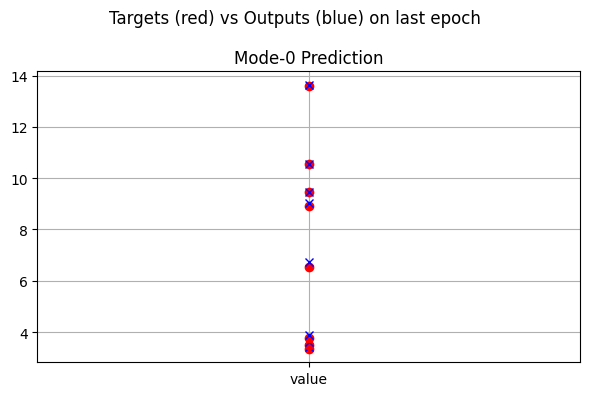

Training, loss: 0.0906: 100%|██████████| 100/100 [1:50:40<00:00, 66.40s/it]

Final Loss of Model: 0.09055876169679312


: 

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import torch.nn as nn

def main(trainloader, testloader):
    os.makedirs("models", exist_ok=True)
    
    # --- Training Configuration ---
    batch_size = 512
    test_batch_size = 1000
    lr = 1e-3
    gamma = 0.9
    epochs = 100
    save_dir = 'blurred_first_mode'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # --- Model & Optimizer ---
    model = Net4_ModeOnly_TiledConditioning_dropout().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()

    # --- Dataset Split ---

    # --- Training Loop ---
    e_loss_graph = []
    train_loss_graph = []
    pbar = tqdm(range(epochs), desc="Training, loss= ----")
    best = 1000
    for epoch in pbar:
        train_loss = train_structured(model, device, train_loader, optimizer, loss_fn)
        e_loss = test_structured(model, device, test_loader, loss_fn, epoch, epochs)
        e_loss_graph.append(e_loss)
        train_loss_graph.append(train_loss)

        # Update progress bar description
        pbar.set_description(f"Training, loss: {e_loss:.4f}")

        # Scheduler step and save model
        scheduler.step()
        if e_loss < best:
          torch.save(model.state_dict(), f"models/{save_dir}.pth")

        # Save updated loss plot
        plt.figure()
        plt.plot(range(epoch + 1), e_loss_graph, label="Test Loss")

        plt.plot(range(epoch + 1), train_loss_graph, label="Training Loss")
        plt.title(f"Test and Training Loss Over Epochs ({save_dir})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"models/{save_dir}.png")
        plt.close()
    print(f'Final Loss of Model: {e_loss}')

if __name__ == '__main__':
    # print(len(test_loader.dataset))
    main(train_loader, test_loader)
